# Tokenization Study

## Datasets: Loading and Cleaning

### Itihasa

In [1]:
import requests

url = "https://raw.githubusercontent.com/rahular/itihasa/main/data/dev.sn"

data = requests.get(url).text.splitlines()

In [2]:
data[:2]

['तस्यां चीरं वसानायां नाथवत्यामनाथवत्। प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥',
 'तेन तत्र प्रणादेन दुःखितः स महीपतिः। चिच्छेद जीविते श्रद्धां धर्मे यशसि चात्मनः॥ स निःश्वस्योष्णमैक्ष्वाकस्तां भार्यामिदमब्रवीत्। कैकेयि कुशचीरेण न सीता गन्तुमर्हति॥']

In [3]:
# searching for Sandhis: This just means that this dataset has sandhis and is not a disolved dataset.

matches = [line for line in data if "ऽ" in line]

print(len(matches))
print(matches[0])

1096
रामेण यदि ते पापे किंचित्कृतमशोभनम्। अपकारः क इह ते वैदेह्या दर्शितोऽधमे॥


In [4]:
# Corpus Statistics:


def corpus_statistics(data):
  """
  corpus statistics
  """

# Calculate metrics for the dataset
  num_verses = num_verses = len(data)

# Calculate num_lines by counting ' । ' and ' ॥ ' delimiters
  num_lines = 0
  for sentence in data:
    num_lines += sentence.count('।')
    num_lines += sentence.count('॥')


  total_characters = sum(len(sentence.replace(' ', '')) for sentence in data)
  total_words = sum(len(sentence.split()) for sentence in data)

  print(f"Number of verses: {num_verses}")
  print(f"Number of lines: {num_lines}")
  print(f"Total characters (excluding spaces): {total_characters}")
  print(f"Total words: {total_words}")

  # Calculate averages
  average_words_per_verse = total_words / num_verses
  average_chars_per_verse = total_characters / num_verses
  average_words_per_line = total_words / num_lines
  average_chars_per_line = total_characters / num_lines

  print(f"\n")
  print(f"Average words per verse: {average_words_per_verse:.2f}")
  print(f"Average characters per verse: {average_chars_per_verse:.2f}")
  print(f"Average words per line: {average_words_per_line:.2f}")
  print(f"Average characters per line: {average_chars_per_line:.2f}")

In [5]:
corpus_statistics(data)

Number of verses: 6148
Number of lines: 14609
Total characters (excluding spaces): 549828
Total words: 71130


Average words per verse: 11.57
Average characters per verse: 89.43
Average words per line: 4.87
Average characters per line: 37.64


### Data Cleaning

Going through all the unicode letters and determining any anomilities:

In [6]:
import unicodedata

unique_chars = sorted(set("".join(data)))

for ch in unique_chars:
    print(
        repr(ch),
        hex(ord(ch)),
        unicodedata.name(ch, "UNKNOWN")
    )

' ' 0x20 SPACE
'!' 0x21 EXCLAMATION MARK
"'" 0x27 APOSTROPHE
'(' 0x28 LEFT PARENTHESIS
')' 0x29 RIGHT PARENTHESIS
',' 0x2c COMMA
'-' 0x2d HYPHEN-MINUS
'.' 0x2e FULL STOP
':' 0x3a COLON
'?' 0x3f QUESTION MARK
'[' 0x5b LEFT SQUARE BRACKET
'_' 0x5f LOW LINE
'ā' 0x101 LATIN SMALL LETTER A WITH MACRON
'ँ' 0x901 DEVANAGARI SIGN CANDRABINDU
'ं' 0x902 DEVANAGARI SIGN ANUSVARA
'ः' 0x903 DEVANAGARI SIGN VISARGA
'अ' 0x905 DEVANAGARI LETTER A
'आ' 0x906 DEVANAGARI LETTER AA
'इ' 0x907 DEVANAGARI LETTER I
'ई' 0x908 DEVANAGARI LETTER II
'उ' 0x909 DEVANAGARI LETTER U
'ऊ' 0x90a DEVANAGARI LETTER UU
'ऋ' 0x90b DEVANAGARI LETTER VOCALIC R
'ए' 0x90f DEVANAGARI LETTER E
'ऐ' 0x910 DEVANAGARI LETTER AI
'ओ' 0x913 DEVANAGARI LETTER O
'औ' 0x914 DEVANAGARI LETTER AU
'क' 0x915 DEVANAGARI LETTER KA
'ख' 0x916 DEVANAGARI LETTER KHA
'ग' 0x917 DEVANAGARI LETTER GA
'घ' 0x918 DEVANAGARI LETTER GHA
'ङ' 0x919 DEVANAGARI LETTER NGA
'च' 0x91a DEVANAGARI LETTER CA
'छ' 0x91b DEVANAGARI LETTER CHA
'ज' 0x91c DEVANAGARI LETTER JA


I] Punctuation:

Traditional Sanskrit manuscripts generally do not contain modern punctuation marks. Therefore, the following symbols could be removed during preprocessing:

'!' 0x21 EXCLAMATION MARK

'(' 0x28 LEFT PARENTHESIS

')' 0x29 RIGHT PARENTHESIS

',' 0x2c COMMA

'-' 0x2d HYPHEN-MINUS

'?' 0x3f QUESTION MARK

'[' 0x5b LEFT SQUARE BRACKET

'_' 0x5f LOW LINE

'—' 0x2014 EM DASH

'‘' 0x2018 LEFT SINGLE QUOTATION MARK

'”' 0x201d RIGHT DOUBLE QUOTATION MARK

'•' 0x2022 BULLET

However, for training a Sanskrit language model, retaining such punctuation may be beneficial because modern digital Sanskrit texts frequently contain these symbols as they are used in everyday nuances.


II] Non-Standard Sanskrit Characters and OCR Artifacts:

The below charachters are definitely not part of standard sanskrit and OCR errors:

'़' 0x93c DEVANAGARI SIGN NUKTA

'ॅ' 0x945 DEVANAGARI VOWEL SIGN CANDRA E

'॑' 0x951 DEVANAGARI STRESS SIGN UDATTA

'॒' 0x952 DEVANAGARI STRESS SIGN ANUDATTA

'ā' 0x101 LATIN SMALL LETTER A WITH MACRON

"'" 0x27 APOSTROPHE

While nukta and anudatta/ udatta are part of vedic sanskrit, they are not a part of standard sanskrit. Since this study focuses on Classical Sanskrit tokenization, these characters are removed.


III] Manual Inspection of Rare Characters

'क़' 0x958 DEVANAGARI LETTER QA

'ऱ' 0x931 DEVANAGARI LETTER RRA

These letters are primarily associated with Hindi and Urdu orthography. Their occurrences in the corpus were manually inspected. As each character occurred only once and was determined to be an OCR or transcription error, it was replaced with its appropriate Sanskrit counterpart.

IV] Character Normalization

The following normalizations were applied:

'.' (U+002E) FULL STOP → '।' (U+0964) DEVANAGARI DANDA

'ॊ' (U+094A) DEVANAGARI VOWEL SIGN SHORT O → 'ो' (U+094B) DEVANAGARI VOWEL SIGN O

In [7]:
for text in data:
    for word in text.split():
        if "ऱ" in word:
            print(word)

नागलोकमपर्यन्तमनेकाविधप्रासादहऱ्यावलभीनि!हशतसंकुलमुच्चावचक्रीडश्चर्यस्थानावकीर्णमपश्यत्॥


In [8]:
for text in data:
    if "ऱ" in text:
        print(text.replace("ऱ", "[ऱ]"))

तमुत्तोऽनुविवेश तेनैव बिलेन प्रविश्य च तं नागलोकमपर्यन्तमनेकाविधप्रासादह[ऱ]्यावलभीनि!हशतसंकुलमुच्चावचक्रीडश्चर्यस्थानावकीर्णमपश्यत्॥


In [9]:
for text in data:
  if "क़" in text:
    print(text)

सुग्रीवेण तु निःशक़ सालमुत्पाट्य तेजसा। गात्रेष्वभिहतो वाली वज्रेणेव महागिरिः॥


In [10]:
import re

# Characters to normalize
REPLACE_MAP = str.maketrans({
    "क़": "क",
    "ऱ": "र",
    "ॊ": "ो",
    ".": "।"
})

# Characters to remove
REMOVE_CHARS = str.maketrans('','',"़ॅ॒॑ā'!(),-?[_—‘”•")

def clean_text(corpus: list):

    cleaned_texts = []

    for sentence in corpus:

        if not isinstance(sentence, str):
            continue

        sentence = sentence.strip()

        # Normalize characters
        sentence = sentence.translate(REPLACE_MAP)

        # Remove unwanted characters
        sentence = sentence.translate(REMOVE_CHARS)

        # Separate Sanskrit punctuation
        sentence = re.sub(r"॥", " ॥ ", sentence)
        sentence = re.sub(r"।", " । ", sentence)

        # Normalize whitespace
        sentence = re.sub(r"\s+", " ", sentence).strip()

        # Skip empty sentences
        if sentence:
            cleaned_texts.append(sentence)

    return cleaned_texts

In [11]:
data = clean_text(data)
data[:2]

['तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥',
 'तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद जीविते श्रद्धां धर्मे यशसि चात्मनः ॥ स निःश्वस्योष्णमैक्ष्वाकस्तां भार्यामिदमब्रवीत् । कैकेयि कुशचीरेण न सीता गन्तुमर्हति ॥']

In [12]:
for text in data:
  if "क़" in text:
    print(text)

In [13]:
corpus_statistics(data)

Number of verses: 6148
Number of lines: 14619
Total characters (excluding spaces): 549581
Total words: 85690


Average words per verse: 13.94
Average characters per verse: 89.39
Average words per line: 5.86
Average characters per line: 37.59


### Word Distribution

In [14]:
words = []

for sentence in data:
    words.extend(sentence.split())

longest_word = max(words, key=len)

print("Longest word:")
print(longest_word)

print("\nLength:")
print(len(longest_word))

Longest word:
नागलोकमपर्यन्तमनेकाविधप्रासादहर्यावलभीनिहशतसंकुलमुच्चावचक्रीडश्चर्यस्थानावकीर्णमपश्यत्

Length:
86


In [15]:
import regex

def lenghth_shabda(text):

    aksharas = regex.findall(
        r'[अ-हॐ][ािीुूृॄॢॣेैोौ]?ं?ः?',
        text
    )

    return len(aksharas)

word = longest_word

print(lenghth_shabda(word))

56


In [16]:
unique_words = set(words)

longest_words = sorted(
    unique_words,
    key=len,
    reverse=True
)

for w in longest_words[:5]:
    print(lenghth_shabda(w), w)

56 नागलोकमपर्यन्तमनेकाविधप्रासादहर्यावलभीनिहशतसंकुलमुच्चावचक्रीडश्चर्यस्थानावकीर्णमपश्यत्
33 उपाध्यायेनोपाध्यायिनीमपृच्छद्भगवत्युपाध्यायेनासम्यनुज्ञातो
32 ततोऽश्वस्यापानमधमत्ततोऽश्वाद्धम्यमानात्सर्वस्त्रोतोभ्यः
30 क्षारतिक्तकटुरूक्षैस्तीक्ष्णविपाकैश्चक्षुष्युपहतोऽन्धो
31 नारायणगुणाश्रयादजरामरादनिन्द्रियादग्राह्यादसम्भवात्


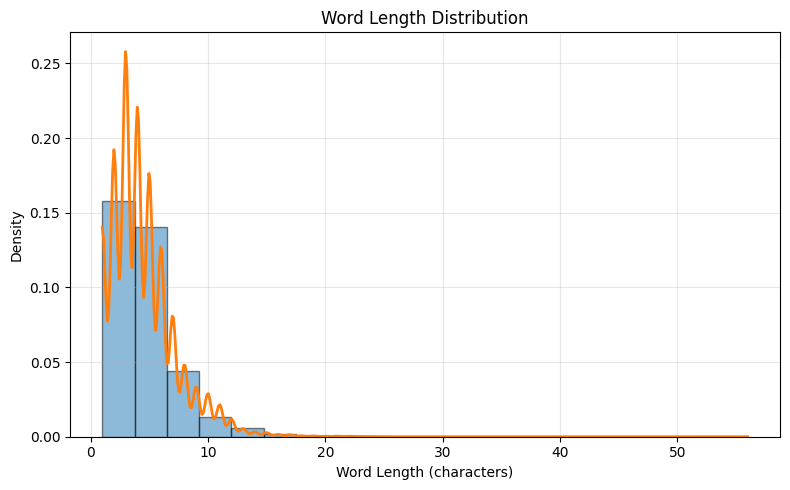

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

word_lengths = [lenghth_shabda(word) for word in words if lenghth_shabda(word) > 0]

# filtered = [x for x in word_lengths if x <= 25]
filtered = [x for x in word_lengths]

plt.figure(figsize=(8,5))

plt.hist(
    filtered,
    bins=20,
    density=True,
    alpha=0.5,
    edgecolor="black"
)

x = np.linspace(min(filtered), max(filtered), 500)
kde = gaussian_kde(filtered)

plt.plot(x, kde(x), linewidth=2)

plt.xlabel("Word Length (characters)")
plt.ylabel("Density")
plt.title("Word Length Distribution")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

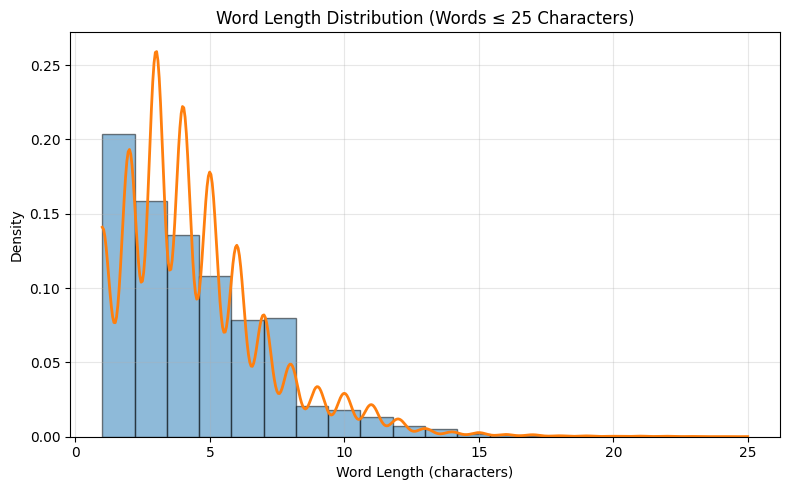

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

filtered = [x for x in word_lengths if x <= 25]

plt.figure(figsize=(8,5))

plt.hist(
    filtered,
    bins=20,
    density=True,
    alpha=0.5,
    edgecolor="black"
)

x = np.linspace(min(filtered), max(filtered), 500)
kde = gaussian_kde(filtered)

plt.plot(x, kde(x), linewidth=2)

plt.xlabel("Word Length (characters)")
plt.ylabel("Density")
plt.title("Word Length Distribution (Words ≤ 25 Characters)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

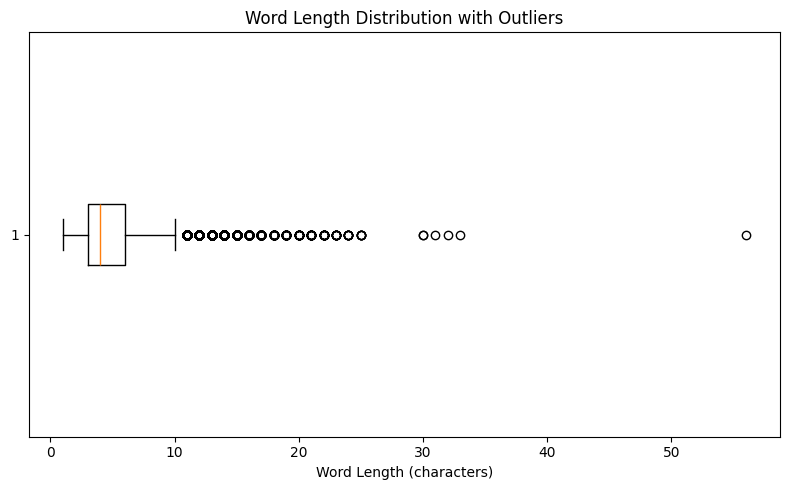

In [19]:
plt.figure(figsize=(8,5))

plt.boxplot(
    word_lengths,
    vert=False
)

plt.xlabel("Word Length (characters)")
plt.title("Word Length Distribution with Outliers")

plt.tight_layout()
plt.show()

In [20]:
import numpy as np

print("Average word lenths:", np.mean(word_lengths))
print("Median:", np.median(word_lengths))
print("25th percentile:", np.percentile(word_lengths, 25))
print("75th percentile:", np.percentile(word_lengths, 75))
print("95th percentile:", np.percentile(word_lengths, 95))
print("99th percentile:", np.percentile(word_lengths, 99))
print("Maximum:", max(word_lengths))
print("Minimum:", min(word_lengths))

Average word lenths: 4.433676704761637
Median: 4.0
25th percentile: 3.0
75th percentile: 6.0
95th percentile: 10.0
99th percentile: 13.0
Maximum: 56
Minimum: 1


## Loading the tokenizers

### GPT Tokenizers for old and new

In [21]:
# they live in the tiktoken environmemt, and here i can use the name as tokenizers using .encode:

import tiktoken
gpt_enc = tiktoken.get_encoding("cl100k_base")
o200k_enc = tiktoken.get_encoding("o200k_base")

### SentencePiece

As used by (Kumar, 2026)

In [22]:
import requests
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/sentencepiece/spm_sa.model

--2026-06-02 07:07:14--  https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/sentencepiece/spm_sa.model
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448781 (438K) [application/octet-stream]
Saving to: ‘spm_sa.model.1’

spm_sa.model.1      100%[===================>] 438.26K  --.-KB/s    in 0.02s   

2026-06-02 07:07:14 (17.7 MB/s) - ‘spm_sa.model.1’ saved [448781/448781]



In [23]:
import sentencepiece as spm
from pathlib import Path

def load_spm(lang: str) -> spm.SentencePieceProcessor:
    sp = spm.SentencePieceProcessor()
    sp.load("spm_sa.model")
    return sp

In [24]:
sp_sa = load_spm("sa")

### SansGPT Tokenizer

In [ ]:
!wget https://raw.githubusercontent.com/rhugvedd/SansGPT-Advancing-Generative-Pre-Training-in-Sanskrit/master/BPETokenizer.py
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/SansGPT/Final-Corpus-Tokenizer-Merge-Info-NL-12000-.pkl
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/SansGPT/Final-Corpus-Tokenizer-Vocab-NL-12000-.pkl

In [26]:
vocab_path = "./"
merge_info_name = "Final-Corpus-Tokenizer-Merge-Info-NL-12000-"
vocab_name = "Final-Corpus-Tokenizer-Vocab-NL-12000-"

In [27]:
# SansGPT BPE Tokenizer:
# as implemented in paper

from BPETokenizer import BPETokenizer

Tokenizer = BPETokenizer()
Tokenizer.load(vocab_path, merge_info_name, vocab_name)

Loaded Vocabulary!
Vocab Size: 12000
MergeInfo Size: 11744


In [28]:
dir(Tokenizer)

['Decode',
 'DecodeVocab',
 'Encode',
 'EncodeFromText',
 'GetBigramStats',
 'GetCleanedText',
 'Merge',
 'MergeInfo',
 'PrintTokenizedText',
 'TrainVocab',
 'TrainVocab_fromText',
 'Vocab',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'count_bigrams',
 'load',
 'save',
 'special_tok',
 'special_tokens']

### Sutra

In [29]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer

login(userdata.get("HF_TOKEN"))

In [30]:
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")

### HF tokenizers

In [31]:
from transformers import AutoTokenizer

claude = AutoTokenizer.from_pretrained("Xenova/claude-tokenizer")
tiny = AutoTokenizer.from_pretrained("openaccess-ai-collective/tiny-mistral")
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")
qwen_sanskrit_model = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-Qwen2.5-7B-base")
qwen_sanskrit_tokenizer = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-English-qwen2-tokenizer")
mt5 = AutoTokenizer.from_pretrained("google/mt5-small")
mbart = AutoTokenizer.from_pretrained("facebook/mbart-large-50")
airavata = AutoTokenizer.from_pretrained("ai4bharat/Airavata") # needs login
llama = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct") # needs login # access granted
aya = AutoTokenizer.from_pretrained("CohereLabs/aya-expanse-8b") # needs login
gemma = AutoTokenizer.from_pretrained("google/gemma-1.1-2b-it") # needs login

## Metadata Tokenizers

In [32]:
import pandas as pd


def tokenizer_metadata_table(tokenizers_dict):

    rows = []

    for label, tok in tokenizers_dict.items():

        row = {
            "label": label,
            "class": getattr(tok, "backend_model", type(tok).__name__),
        }

        # -----------------------------
        # vocab size
        # -----------------------------

        if hasattr(tok, "vocab_size"):
          vocab = tok.vocab_size

          if callable(vocab):
            row["vocab_size"] = vocab()
          else:
            row["vocab_size"] = vocab

        elif hasattr(tok, "n_vocab"):

          row["vocab_size"] = tok.n_vocab

        elif hasattr(tok, "Vocab"):
          try:
            row["vocab_size"] = len(tok.Vocab)
          except:
            row["vocab_size"] = "not available"

        else:

          row["vocab_size"] = "not available"

        # -----------------------------
        # model path / tokenizer name
        # -----------------------------
        if hasattr(tok, "name_or_path"):

            row["model_path"] = tok.name_or_path

        elif hasattr(tok, "name"):

            row["model_path"] = tok.name

        elif hasattr(tok, "MergeInfo"):
          row["model_path"] = tok.__class__.__name__

        else:

            row["model_path"] = "not available"


        # -----------------------------
        # backend tokenizer model
        # -----------------------------
        try:

            row["backend_model"] = str(tok.backend_tokenizer.model)

        except:
          if hasattr(tok, "backend_model"):
            row["backend_model"] = tok.backend_model

          else:
            row["backend_model"] = tok.__class__.__name__


        # -----------------------------
        # special tokens
        # -----------------------------
        try:

            row["special_tokens"] = tok.special_tokens_map

        except:
          if hasattr(tok, "special_tokens"):
            row["special_tokens"] = tok.special_tokens

          elif hasattr(tok, "special_tok"):
            row["special_tokens"] = tok.special_tok

          else:
            try:
              row["special_tokens"] = tok._special_tokens
            except:
              row["special_tokens"] = "not available"

        # -----------------------------
        # sentencepiece model
        # -----------------------------

        if type(tok).__name__ == "SentencePieceProcessor":
          row["model_path"] = getattr(tok, "_model_file", "SentencePiece Model")
          row["backend_model"] = type(tok).__name__

          try:
            row["special_tokens"] = {
                "unk_id": tok.unk_id(),
                "bos_id": tok.bos_id(),
                "eos_id": tok.eos_id(),
                "pad_id": tok.pad_id()
                }
          except:
            row["special_tokens"] = "not available"

        rows.append(row)

    meta_df = pd.DataFrame(rows)

    return meta_df

In [33]:
tokenizers = {

    "claude": claude,
    "tiny_mistral": tiny,
    "sutra": sutra,
    "qwen_sanskrit_model": qwen_sanskrit_model,
    "qwen_sanskrit_tokenizer": qwen_sanskrit_tokenizer,
    "mt5": mt5,
    "mbart": mbart,
    "airavata" : airavata, # needs login
    "llama": llama, # needs login # access granted
    "aya": aya, # needs login
    "gemma": gemma, # needs login
    "cl100k_base": gpt_enc,
    "o200k_base": o200k_enc,
    "sentencepiece_sa": sp_sa,
    "sansgpt_tokenizer": Tokenizer
}

meta_df = tokenizer_metadata_table(tokenizers)

meta_df

,label,class,vocab_size,model_path,backend_model,special_tokens
0,claude,GPT2Tokenizer,65000,Xenova/claude-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<EOT>', 'eos_token': '<EOT>', '..."
1,tiny_mistral,TokenizersBackend,32000,openaccess-ai-collective/tiny-mistral,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
2,sutra,TokenizersBackend,256001,TWO/sutra-mlt256-v2,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
3,qwen_sanskrit_model,Qwen2Tokenizer,151643,diabolic6045/Sanskrit-Qwen2.5-7B-base,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|endoftext|>', 'pad_token': '<..."
4,qwen_sanskrit_tokenizer,TokenizersBackend,120000,diabolic6045/Sanskrit-English-qwen2-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|im_end|>', 'unk_token': '<unk..."
5,mt5,T5Tokenizer,250100,google/mt5-small,"Unigram(unk_id=2, vocab=[(""<pad>"", 0), (""</s>""...","{'eos_token': '</s>', 'unk_token': '<unk>', 'p..."
6,mbart,MBart50Tokenizer,250054,facebook/mbart-large-50,"Unigram(unk_id=3, vocab=[(""<s>"", 0), (""<pad>"",...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
7,airavata,TokenizersBackend,48064,ai4bharat/Airavata,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
8,llama,TokenizersBackend,128000,meta-llama/Llama-3.1-8B-Instruct,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<|begin_of_text|>', 'eos_token'..."
9,aya,CohereTokenizer,255000,CohereLabs/aya-expanse-8b,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<BOS_TOKEN>', 'eos_token': '<|E..."


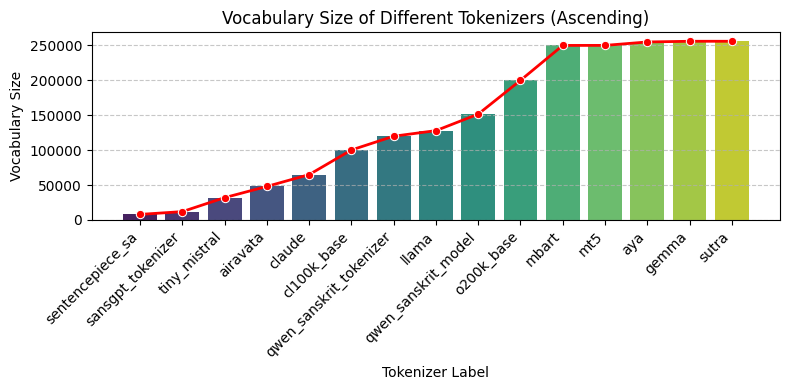

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort meta_df by vocab_size in ascending order
sorted_meta_df = meta_df.sort_values(by='vocab_size', ascending=True)

plt.figure(figsize=(8, 4))
sns.barplot(x='label', y='vocab_size', data=sorted_meta_df, palette='viridis', hue='label', legend=False, order=sorted_meta_df['label'])
# Add a rising red line
sns.lineplot(x='label', y='vocab_size', data=sorted_meta_df, color='red', marker='o', linewidth=2, sort=False)
plt.title('Vocabulary Size of Different Tokenizers (Ascending)')
plt.xlabel('Tokenizer Label')
plt.ylabel('Vocabulary Size')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Evaluation

In [35]:
import pandas as pd
import numpy as np
from google.colab import files
import contextlib
import io
from tqdm.auto import tqdm


def tokenize(data: list, tokenizer, tokenizer_label):
    """
    Tokenizes each sentence individually.
    Returns a DataFrame — one row per sentence.
    """

    records = []

    for sentence in tqdm(data, desc=tokenizer_label):

        if not sentence.strip():
            continue

        # -----------------------------
        # SansGPT
        # -----------------------------
        if type(tokenizer).__name__ == "BPETokenizer":

            with contextlib.redirect_stdout(io.StringIO()):

                tokens = tokenizer.EncodeFromText(
                    sentence,
                    WithoutNewLine=False,
                    SkipFirstChunkInLine=False,
                    Replacements={}
                )

            # token_strings = [
            #     tokenizer.Decode(chunk)
            #     for chunk in tokens
            # ]

            decoded = "".join(
                tokenizer.Decode(chunk)
                for chunk in tokens
            )

        # -----------------------------
        # All other tokenizers
        # -----------------------------
        else:

            tokens = tokenizer.encode(sentence)

            # try:
            #     token_strings = tokenizer.tokenize(sentence)
            #
            # except:
            #     token_strings = [
            #         tokenizer.decode([t])
            #         for t in tokens
            #     ]

            try:
                decoded = tokenizer.decode(
                    tokens,
                    skip_special_tokens=True
                )

            except:
                decoded = tokenizer.decode(tokens)

        # -----------------------------
        # Common calculations
        # -----------------------------

        words = sentence.split()

        num_words = len(words)
        num_tokens = len(tokens)

        num_chars = len(
            sentence.replace(" ", "")
        )

        records.append({

            "sentence": sentence,
            "decoded_sentence": decoded,

            # "tokens": token_strings,

            "similarity": sentence.strip() == decoded.strip(),

            "num_words": num_words,
            "num_tokens": num_tokens,

            # "unique_tokens_count": len(set(tokens)),

            "token_ids": tokens,

            "num_chars": num_chars,

            "fertility": (
                num_tokens / num_words
                if num_words > 0 else None
            ),

            "tokens_per_char": (
                num_tokens / num_chars
                if num_chars > 0 else None
            ),

            "chars_per_token": (
                num_chars / num_tokens
                if num_tokens > 0 else None
            ),

            "tokenizer": tokenizer_label
        })

    df = pd.DataFrame(records)

    return df

## Tokenizer wise results:

In [36]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    ("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),
    ("sentencepiece_sa", sp_sa),
    ("sansgpt", Tokenizer)

]

for tok, name in tokenizers:
  print(f"Running {name}")
  temp_df = tokenize(data, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

Running GPT2Tokenizer(name_or_path='Xenova/claude-tokenizer', vocab_size=65000, model_max_length=200000, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<EOT>', 'eos_token': '<EOT>', 'unk_token': '<EOT>'}, added_tokens_decoder={
	0: AddedToken("<EOT>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<META>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<META_START>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<META_END>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<SOS>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


claude:   0%|          | 0/6148 [00:00<?, ?it/s]

Running TokenizersBackend(name_or_path='openaccess-ai-collective/tiny-mistral', vocab_size=32000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>'}, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)


tiny:   0%|          | 0/6148 [00:00<?, ?it/s]

Running TokenizersBackend(name_or_path='TWO/sutra-mlt256-v2', vocab_size=256001, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256001: AddedToken("hin_Deva", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256002: AddedToken("ben_Beng", rstrip=False, lstrip=False, single_word=False, normalized=False, special=Tr

...

o200k_base:   0%|          | 0/6148 [00:00<?, ?it/s]

Running <sentencepiece.SentencePieceProcessor; proxy of <Swig Object of type 'sentencepiece::SentencePieceProcessor *' at 0x7bec82841e90> >


sentencepiece_sa:   0%|          | 0/6148 [00:00<?, ?it/s]

Running <BPETokenizer.BPETokenizer object at 0x7bec8266d850>


sansgpt:   0%|          | 0/6148 [00:00<?, ?it/s]

In [37]:
# uncomment to download a file

"""
filename = f"tokenizer_analysis.xlsx"

df.to_excel(filename, index=False)

files.download(filename)
"""


'\nfilename = f"tokenizer_analysis.xlsx"\n\ndf.to_excel(filename, index=False)\n\nfiles.download(filename)\n'

In [38]:
df_sp = df[df['tokenizer']=="sentencepiece_sa"]
df_sp = df_sp[df_sp['similarity']== False]
df_sp.head()

,sentence,decoded_sentence,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
79924,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,False,13,38,"[7351, 23, 2116, 5312, 10, 97, 31, 502, 7967, ...",73,2.923077,0.520548,1.921053,sentencepiece_sa
79925,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दु ⁇ खित ⁇ स महीपति ⁇ । चि...,False,24,71,"[1744, 856, 30, 271, 7953, 70, 275, 0, 7979, 2...",146,2.958333,0.486301,2.056338,sentencepiece_sa
79926,सुकुमारी च बाला च सततं च सुखोचिता । नेयं वनस्य...,सुकुमारी च बाला च सततं च सुखोचिता । नेयं वनस्य...,False,14,32,"[571, 7950, 442, 45, 7965, 23, 62, 7938, 637, ...",61,2.285714,0.524590,1.906250,sentencepiece_sa
79927,इयं हि कस्यापि करोति किंचित् तपस्विनी राजवरस्य...,इयं हि कस्यापि करोति किंचित् तपस्विनी राजवरस्य...,False,18,37,"[194, 159, 220, 5356, 1158, 2517, 616, 2159, 3...",95,2.055556,0.389474,2.567568,sentencepiece_sa
79928,चीराण्यपास्याज्जनकस्य कन्या नेयं प्रतिज्ञा मम ...,चीराण्यपास्याज्जनकस्य कन्या नेयं प्रतिज्ञा मम ...,False,15,41,"[23, 7965, 823, 4, 7949, 655, 7938, 36, 884, 2...",96,2.733333,0.427083,2.341463,sentencepiece_sa


In [39]:
from collections import Counter

bad_chars = Counter()

failures = df_sp[
    df_sp["decoded_sentence"].str.contains("⁇", regex=False)
]

failures[["sentence", "decoded_sentence"]].head(20)

for _, row in failures.iterrows():

    original = row["sentence"]
    decoded = row["decoded_sentence"]

    if "⁇" in decoded:

        idxs = [i for i, c in enumerate(decoded) if c == "⁇"]

        for idx in idxs:
            if idx < len(original):
                bad_chars[original[idx]] += 1

print(bad_chars.most_common(20))

[(' ', 5505), ('्', 684), ('र', 365), ('ा', 362), ('त', 259), ('ु', 239), ('ि', 206), ('स', 168), ('व', 162), ('म', 156), ('न', 142), ('श', 108), ('प', 108), ('े', 101), ('द', 100), ('ष', 99), ('क', 94), ('ह', 94), ('य', 94), ('ं', 90)]


In [40]:
df['tokenizer'].unique()

array(['claude', 'tiny', 'sutra', 'qwen_sanskrit_model',
       'qwen_sanskrit_tokenizer', 'mt5', 'mbart', 'airavata', 'llama',
       'aya', 'gemma', 'cl100k_base', 'o200k_base', 'sentencepiece_sa',
       'sansgpt'], dtype=object)

In [41]:
df.head(2)

,sentence,decoded_sentence,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,True,13,102,"[45793, 56377, 38639, 5333, 112, 24332, 40786,...",73,7.846154,1.397260,0.715686,claude
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,True,24,202,"[45793, 29050, 37134, 13348, 102, 45793, 38639...",146,8.416667,1.383562,0.722772,claude


In [42]:
df.tail(2)

,sentence,decoded_sentence,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
92218,योनिस्त्वमस्य प्रलयश्च कृष्ण त्वमेवेदं सृजसे व...,योनिस्त्वमस्य प्रलयश्च कृष्ण त्वमेवेदं सृजसे व...,True,15,56,"[[224, 164, 175], [268, 139, 224, 164, 168], [...",103,3.733333,0.543689,1.839286,sansgpt
92219,एवं स्तुतो धर्मराजेन कृष्णः सभामध्ये प्रीतिमान...,एवं स्तुतो धर्मराजेन कृष्णः सभामध्ये प्रीतिमान...,True,15,63,"[[224, 164, 143, 224, 164, 181], [224, 164, 13...",114,4.200000,0.552632,1.809524,sansgpt


In [43]:
df[df['sentence'] == "तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥ "]

,sentence,decoded_sentence,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer


### Encoding and Decoding Similarity:

In [44]:
df['similarity'].value_counts()

,count
similarity,
True,80009
False,12211


In [45]:
df[df['similarity'] == False][['similarity','tokenizer']].drop_duplicates()

,similarity,tokenizer
12296,False,sutra
79924,False,sentencepiece_sa


## Summary of Metrices

In [46]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)
summary_round

,num_words,num_tokens,fertility,tokens_per_char,chars_per_token
tokenizer,,,,,
qwen_sanskrit_tokenizer,13.9,20.8,1.5,0.2,4.4
sentencepiece_sa,13.9,37.8,2.8,0.4,2.4
mbart,13.9,41.5,3.1,0.5,2.2
sansgpt,13.9,48.4,3.5,0.5,1.8
mt5,13.9,48.4,3.6,0.5,1.8
o200k_base,13.9,48.6,3.6,0.5,1.8
sutra,13.9,49.3,3.6,0.6,1.8
gemma,13.9,52.5,3.9,0.6,1.7
airavata,13.9,59.7,4.4,0.7,1.5


In [47]:
summary_fertility = (
    df.groupby("tokenizer")["fertility"]
      .agg(["mean", "std", "median", "min", "max"])
      .round(2)
)

summary_fertility

,mean,std,median,min,max
tokenizer,,,,,
airavata,4.39,0.88,4.27,2.35,12.4
aya,6.01,1.24,5.82,3.00,15.6
cl100k_base,8.04,1.55,7.82,2.00,20.4
claude,9.30,1.85,9.00,2.00,23.5
gemma,3.86,0.78,3.75,2.00,10.6
llama,4.49,0.83,4.36,2.52,11.2
mbart,3.06,0.62,3.00,1.71,8.4
mt5,3.55,0.62,3.45,2.18,8.8
o200k_base,3.57,0.73,3.46,1.00,10.0


/tmp/ipykernel_18360/3856549932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


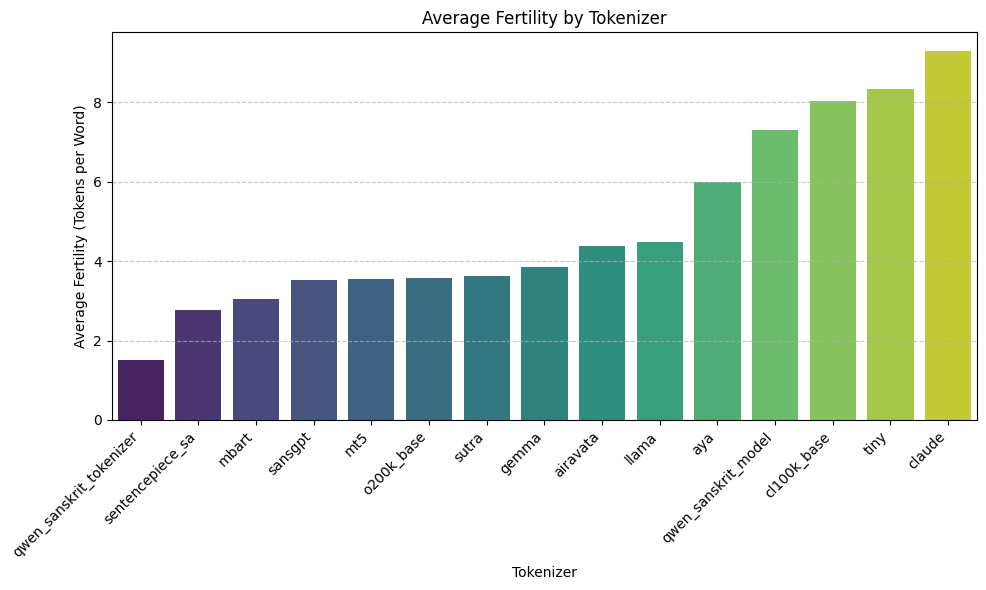

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 1500x1500 with 0 Axes>

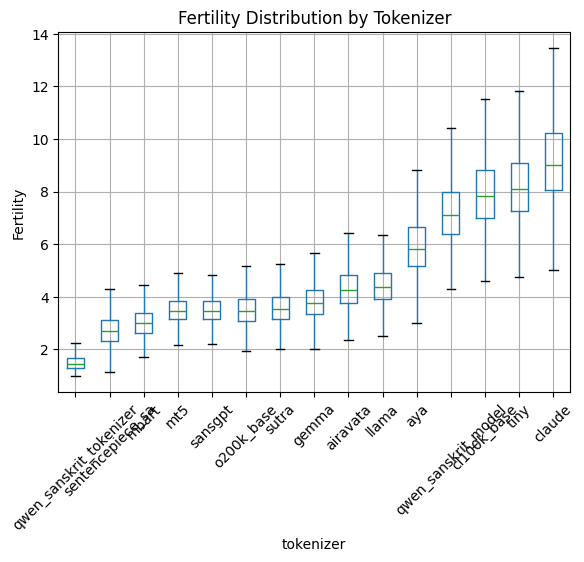

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

order = (
    df.groupby("tokenizer")["fertility"]
      .median()
      .sort_values()
      .index
)


# Convert 'tokenizer' column to a categorical type with the specified order
df["tokenizer"] = pd.Categorical(df["tokenizer"], categories=order, ordered=True)

plt.figure(figsize=(15,15))

df.boxplot(
    column="fertility",
    by="tokenizer",
    rot=45,
    showfliers=False
)

plt.ylabel("Fertility")
plt.title("Fertility Distribution by Tokenizer")
plt.suptitle("")
plt.show()

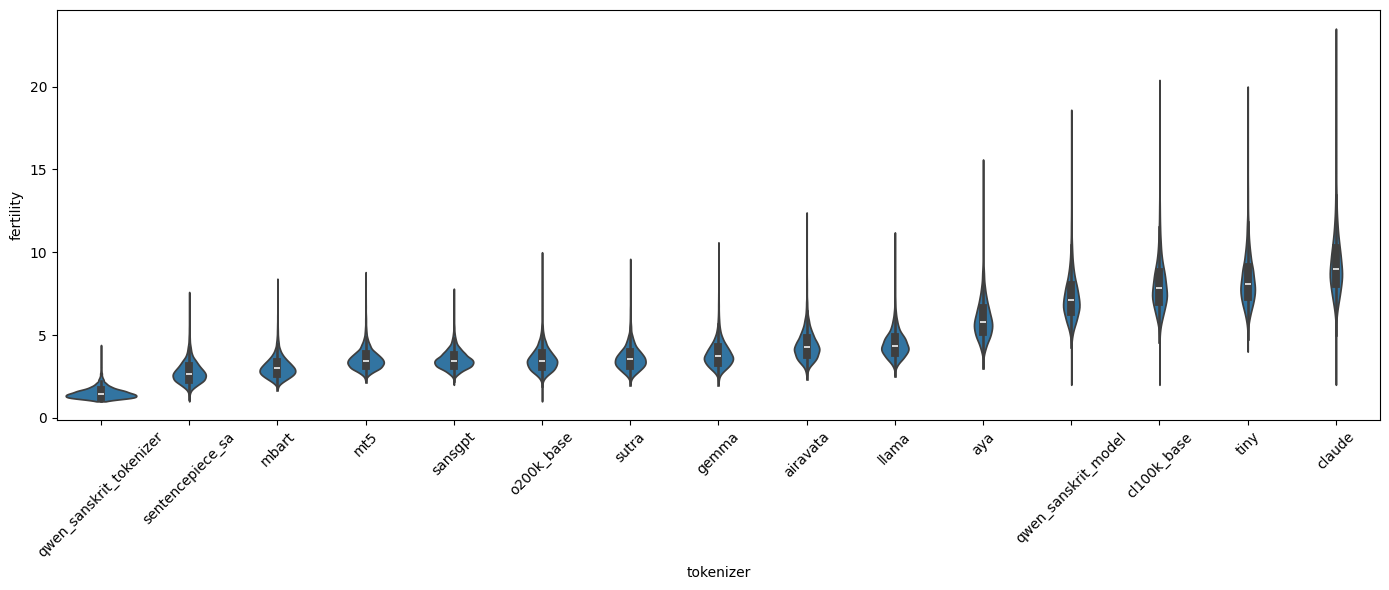

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="tokenizer",
    y="fertility",
    cut=0
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

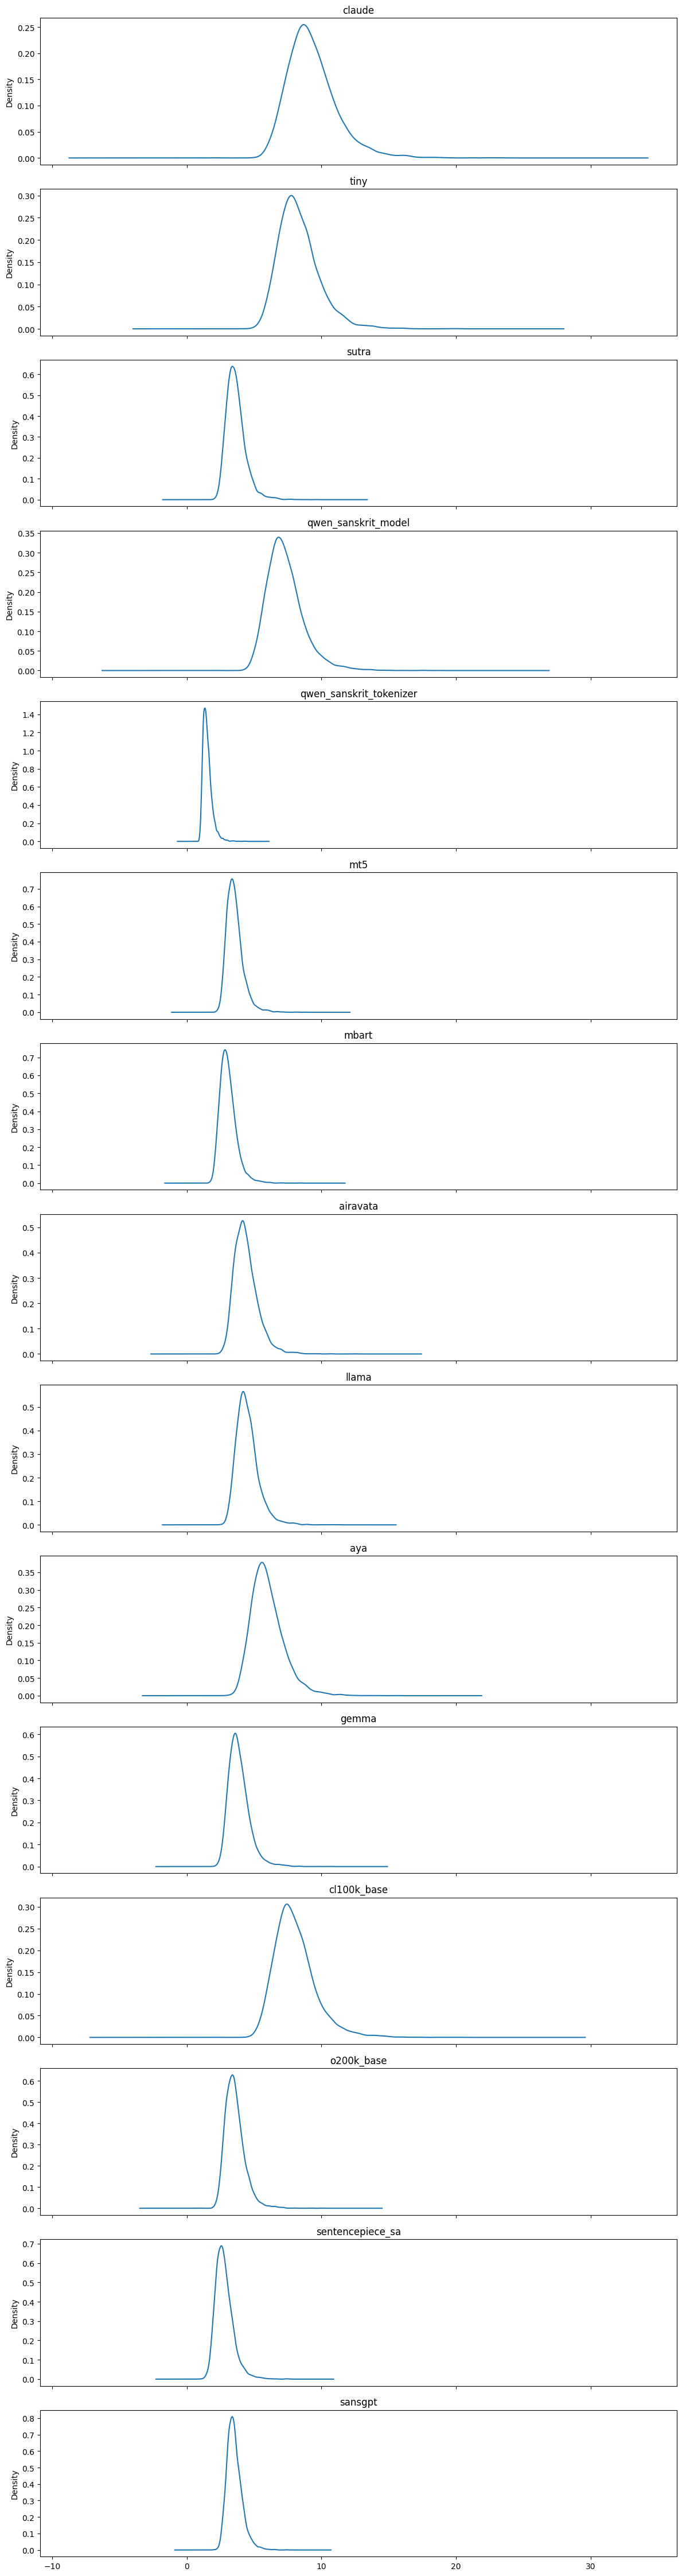

In [51]:
import matplotlib.pyplot as plt

tokenizers = df["tokenizer"].unique()

fig, axes = plt.subplots(
    len(tokenizers),
    1,
    figsize=(12, 3*len(tokenizers)),
    sharex=True
)

for ax, tok in zip(axes, tokenizers):

    subset = df[df["tokenizer"] == tok]

    subset["fertility"].plot(
        kind="kde",
        ax=ax
    )

    ax.set_title(tok)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


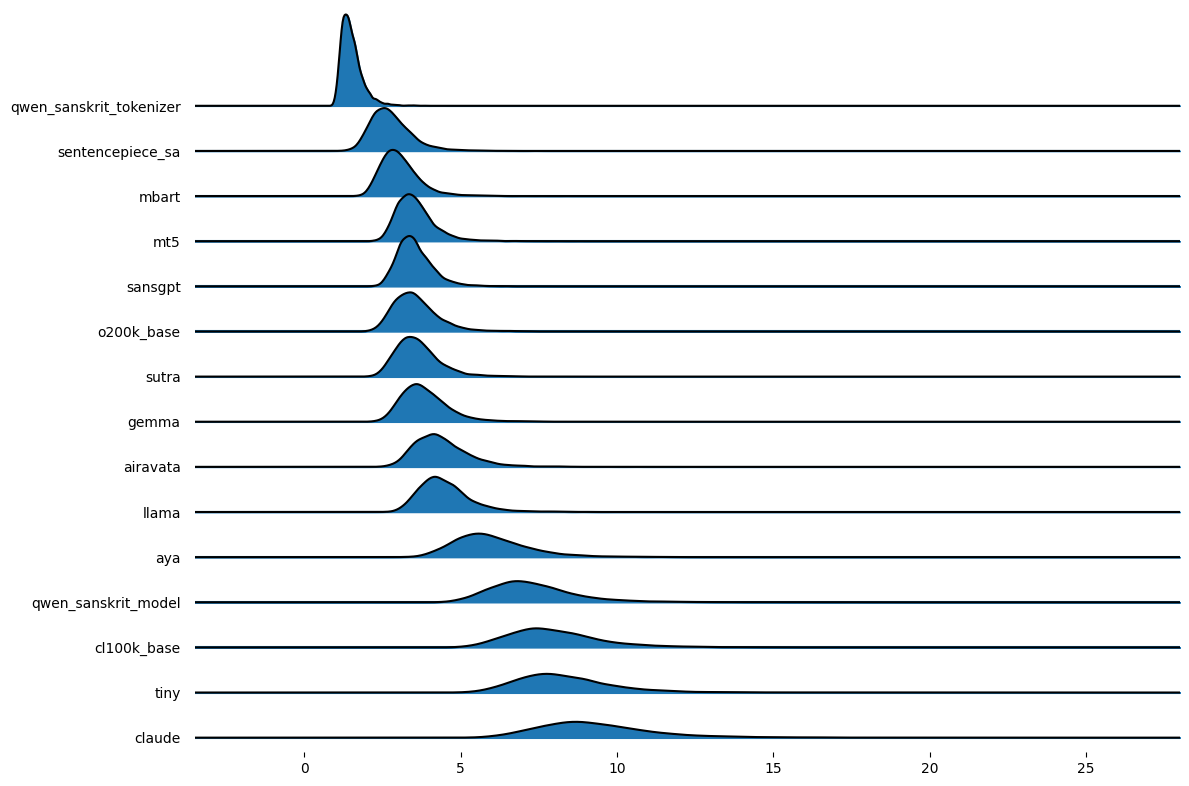

In [53]:
!pip install joypy
import joypy
import matplotlib.pyplot as plt

joypy.joyplot(
    df,
    by="tokenizer",
    column="fertility",
    figsize=(12,8)
)

plt.show()

# Vedic Corpus

In [ ]:
# !pip install datasets

In [ ]:
from datasets import load_dataset
vedic = load_dataset("shunyasea/vedic-sanskrit")

In [ ]:
print(vedic)

In [ ]:
vedic = vedic["test"]["text"]

In [ ]:
vedic[:5]

In [ ]:
print(len(vedic))

In [ ]:
# size of dataset, one wants to set
import random

random.seed(42)
n = 5000
vedic = random.sample(vedic, n)

print(len(vedic))

In [ ]:
vedic = clean_text(vedic)

In [ ]:
corpus_statistics(vedic)

In [ ]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    ("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),
    ("sentencepiece_sa", sp_sa),
    ("sansgpt", Tokenizer)



]

for tok, name in tokenizers:
  temp_df = tokenize(vedic, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

In [ ]:
df.tail()

In [ ]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)
summary_round

In [ ]:
df[df['similarity'] == False][['similarity','tokenizer']].drop_duplicates()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()